In [ ]:
import os, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, norm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_val_score,
    train_test_split, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from matplotlib.patches import Patch
import matplotlib.patheffects as pe


try:
    import adjustText
except ImportError:
    subprocess.run(['pip', 'install', 'adjustText', '-q'])
    import adjustText

warnings.filterwarnings('ignore')
DATA_DIR = '/content'
OUT_DIR  = '/content/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

C = dict(mild='#4DA6FF', severe='#FF6B6B', prot='#52B788', metab='#F4A261',
         m1='#2196F3', m2='#E76F51', combined='#9B72CF')

plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'figure.facecolor':'white',
                     'axes.facecolor':'#F8F9FA','axes.grid':True,'grid.alpha':0.3})

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Load Data & Remove Healthy Controls

prot_raw  = pd.read_csv(os.path.join(DATA_DIR, 'Final_Separate_Prot.csv'))
metab_raw = pd.read_csv(os.path.join(DATA_DIR, 'Final_Separate_Metab.csv'))

print('Before filtering:', prot_raw.shape)
print('Severity counts:\n', prot_raw['severity'].value_counts())


healthy_mask = prot_raw['samples'] != 'Healthy'
prot  = prot_raw[healthy_mask].reset_index(drop=True)
metab = metab_raw[healthy_mask].reset_index(drop=True)

assert len(prot) == len(metab), \
    f"Row count mismatch: prot={len(prot)}, metab={len(metab)}. Check CSV row order."
print(f'\nAlignment check passed: {len(prot)} rows in both dataframes.')

print('\nAfter removing Healthy:', prot.shape)
print('Severity counts:\n', prot['severity'].value_counts())


META_COLS_BASE = ['sampleid', 'samples', 'age', 'sex', 'severity']
META_COLS_P = [c for c in META_COLS_BASE if c in prot.columns]
META_COLS_M = [c for c in META_COLS_BASE if c in metab.columns]

feat_cols_p = [c for c in prot.columns  if c not in META_COLS_P]
feat_cols_m = [c for c in metab.columns if c not in META_COLS_M]


Xp_raw = prot[feat_cols_p].apply(pd.to_numeric, errors='coerce').fillna(0).values
Xm_raw = np.log1p(metab[feat_cols_m].apply(pd.to_numeric, errors='coerce').fillna(0).values)


y = (prot['severity'] == 'Severe').astype(int).values


age_vals = prot['age'].fillna(prot['age'].median()).values.reshape(-1, 1)
sex_vals = (prot['sex'] == 'Male').astype(float).values.reshape(-1, 1)
cov_raw  = np.hstack([age_vals, sex_vals])

print(f'\nProteomics: {Xp_raw.shape}, Metabolomics: {Xm_raw.shape}')
print(f'Mild: {(y==0).sum()}, Severe: {(y==1).sum()}')


Before filtering: (147, 459)
Severity counts:
 severity
Mild      84
Severe    63
Name: count, dtype: int64

Alignment check passed: 129 rows in both dataframes.

After removing Healthy: (129, 459)
Severity counts:
 severity
Mild      66
Severe    63
Name: count, dtype: int64

Proteomics: (129, 455), Metabolomics: (129, 560)
Mild: 66, Severe: 63


Variable            Mild (n=66)  Severe (n=63)
Age (mean+/-SD)     47.8+/-15.2  64.6+/-16.6  p=0.0
Sex (Male n)        12 (18%)  38 (60%)  p=0.0


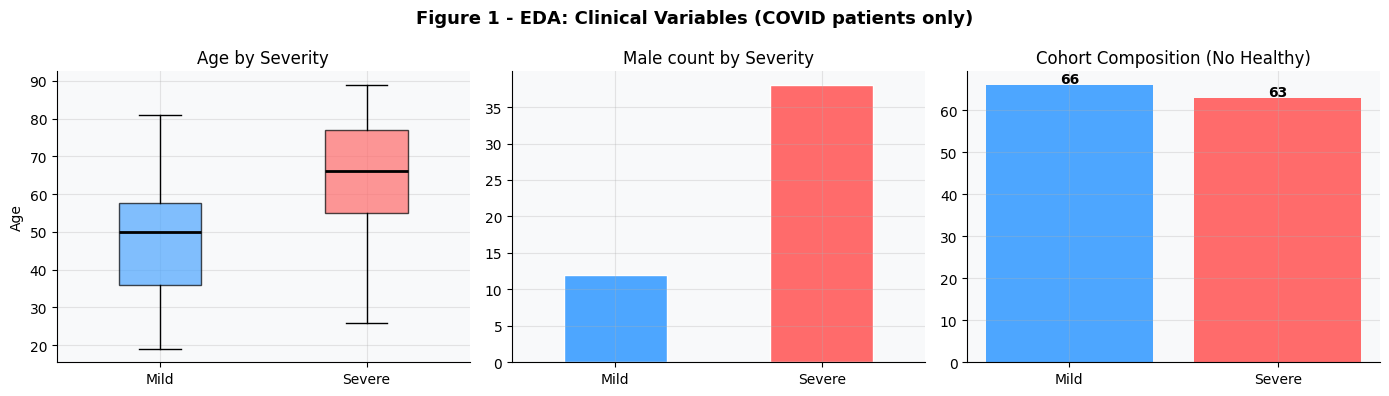

In [ ]:
# EDA

groups = {g: prot[prot['severity']==g] for g in ['Mild','Severe']}

print('='*55)
mild_n = len(groups['Mild']); sev_n = len(groups['Severe'])
print('Variable            Mild (n='+str(mild_n)+')  Severe (n='+str(sev_n)+')')
print('='*55)


from scipy.stats import ttest_ind
age_m = groups['Mild']['age'].dropna()
age_s = groups['Severe']['age'].dropna()
t, p  = ttest_ind(age_m, age_s)
print('Age (mean+/-SD)     '+str(round(age_m.mean(),1))+'+/-'+str(round(age_m.std(),1))
      +'  '+str(round(age_s.mean(),1))+'+/-'+str(round(age_s.std(),1))+'  p='+str(round(p,3)))

# Sex
m_male = (groups['Mild']['sex']=='Male').sum()
s_male = (groups['Severe']['sex']=='Male').sum()
tab = [[m_male, len(groups['Mild'])-m_male],[s_male, len(groups['Severe'])-s_male]]
chi2_stat, p_sex, _, _ = chi2_contingency(tab)
print('Sex (Male n)        '+str(m_male)+' ('+str(round(100*m_male/len(groups['Mild'])))
      +'%)  '+str(s_male)+' ('+str(round(100*s_male/len(groups['Severe'])))+'%)  p='+str(round(p_sex,3)))
print('='*55)

# Visualise age & sex distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 1 - EDA: Clinical Variables (COVID patients only)', fontsize=13, fontweight='bold')

# Age boxplot
ax = axes[0]
for lbl, col in [('Mild', C['mild']), ('Severe', C['severe'])]:
    vals = prot[prot['severity']==lbl]['age'].dropna()
    bp = ax.boxplot(vals, positions=[list(['Mild','Severe']).index(lbl)+1],
                    patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', lw=2))
    bp['boxes'][0].set_facecolor(col); bp['boxes'][0].set_alpha(0.7)
ax.set_xticks([1,2]); ax.set_xticklabels(['Mild','Severe'])
ax.set_ylabel('Age'); ax.set_title('Age by Severity')

# Sex bar
ax = axes[1]
sex_df = prot.groupby(['severity','sex']).size().unstack(fill_value=0)
if 'Male' in sex_df.columns:
    sex_df['Male'].plot(kind='bar', ax=ax, color=[C['mild'],C['severe']], edgecolor='white')
ax.set_title('Male count by Severity'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# Severity count
ax = axes[2]
counts = prot['severity'].value_counts()
ax.bar(counts.index, counts.values,
       color=[C['mild'] if x=='Mild' else C['severe'] for x in counts.index])
ax.set_title('Cohort Composition (No Healthy)')
for i, (v, c) in enumerate(zip(counts.values, counts.index)):
    ax.text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'fig1_eda_clinical.png'), dpi=140, bbox_inches='tight')
plt.show()


--- CELL 3b: Improved PCA Plots ---

Proteomics:


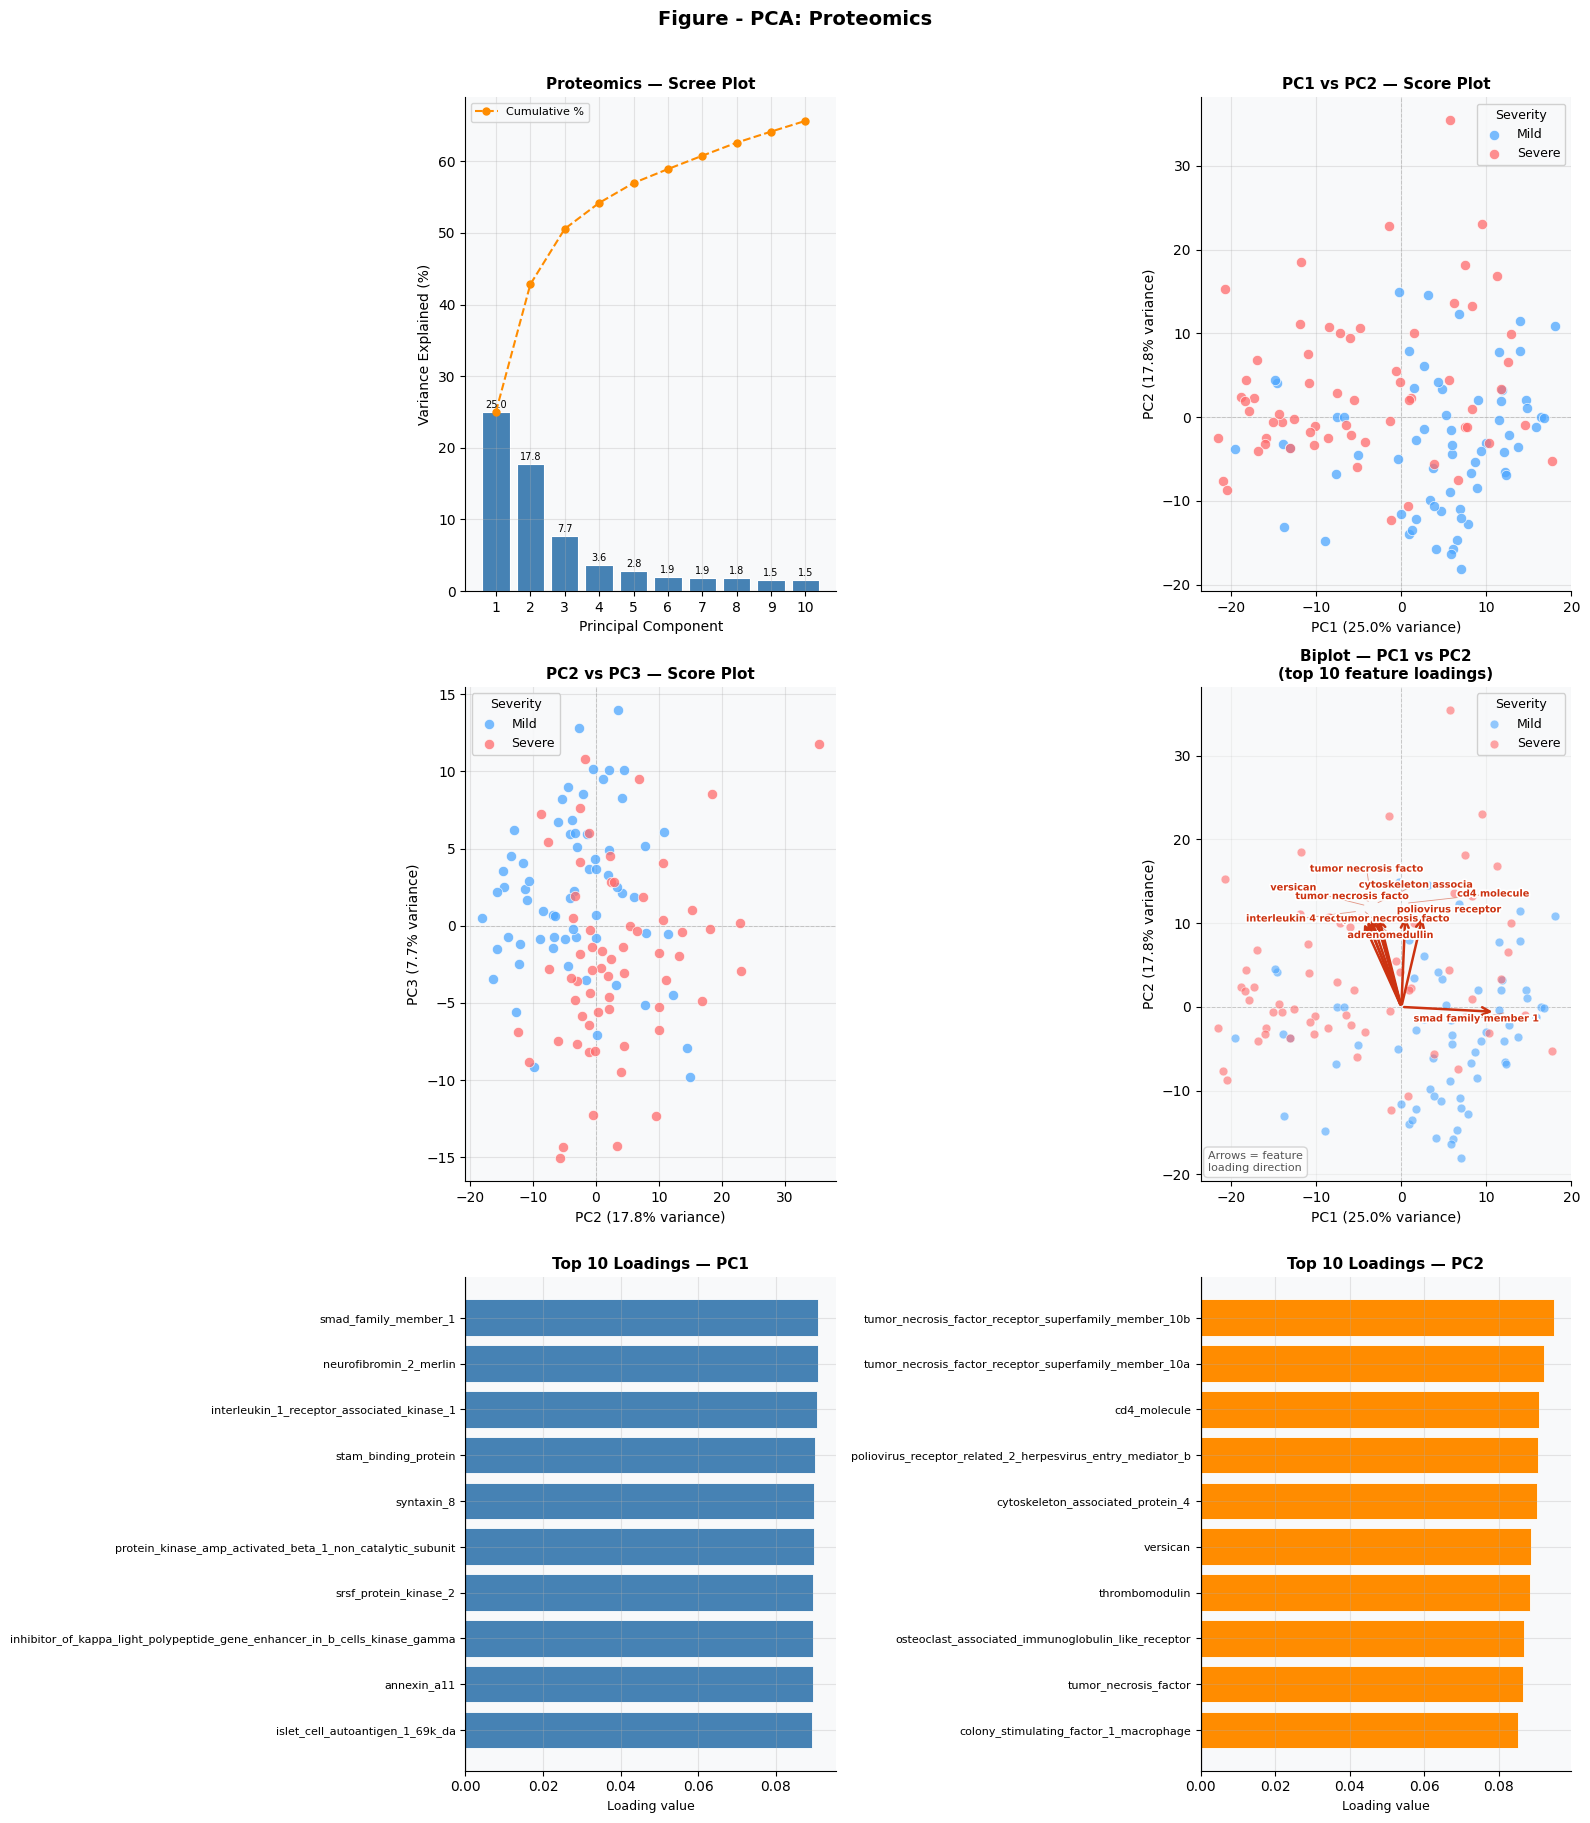

  Saved: fig2b_pca_proteomics_v2.png

Metabolomics:


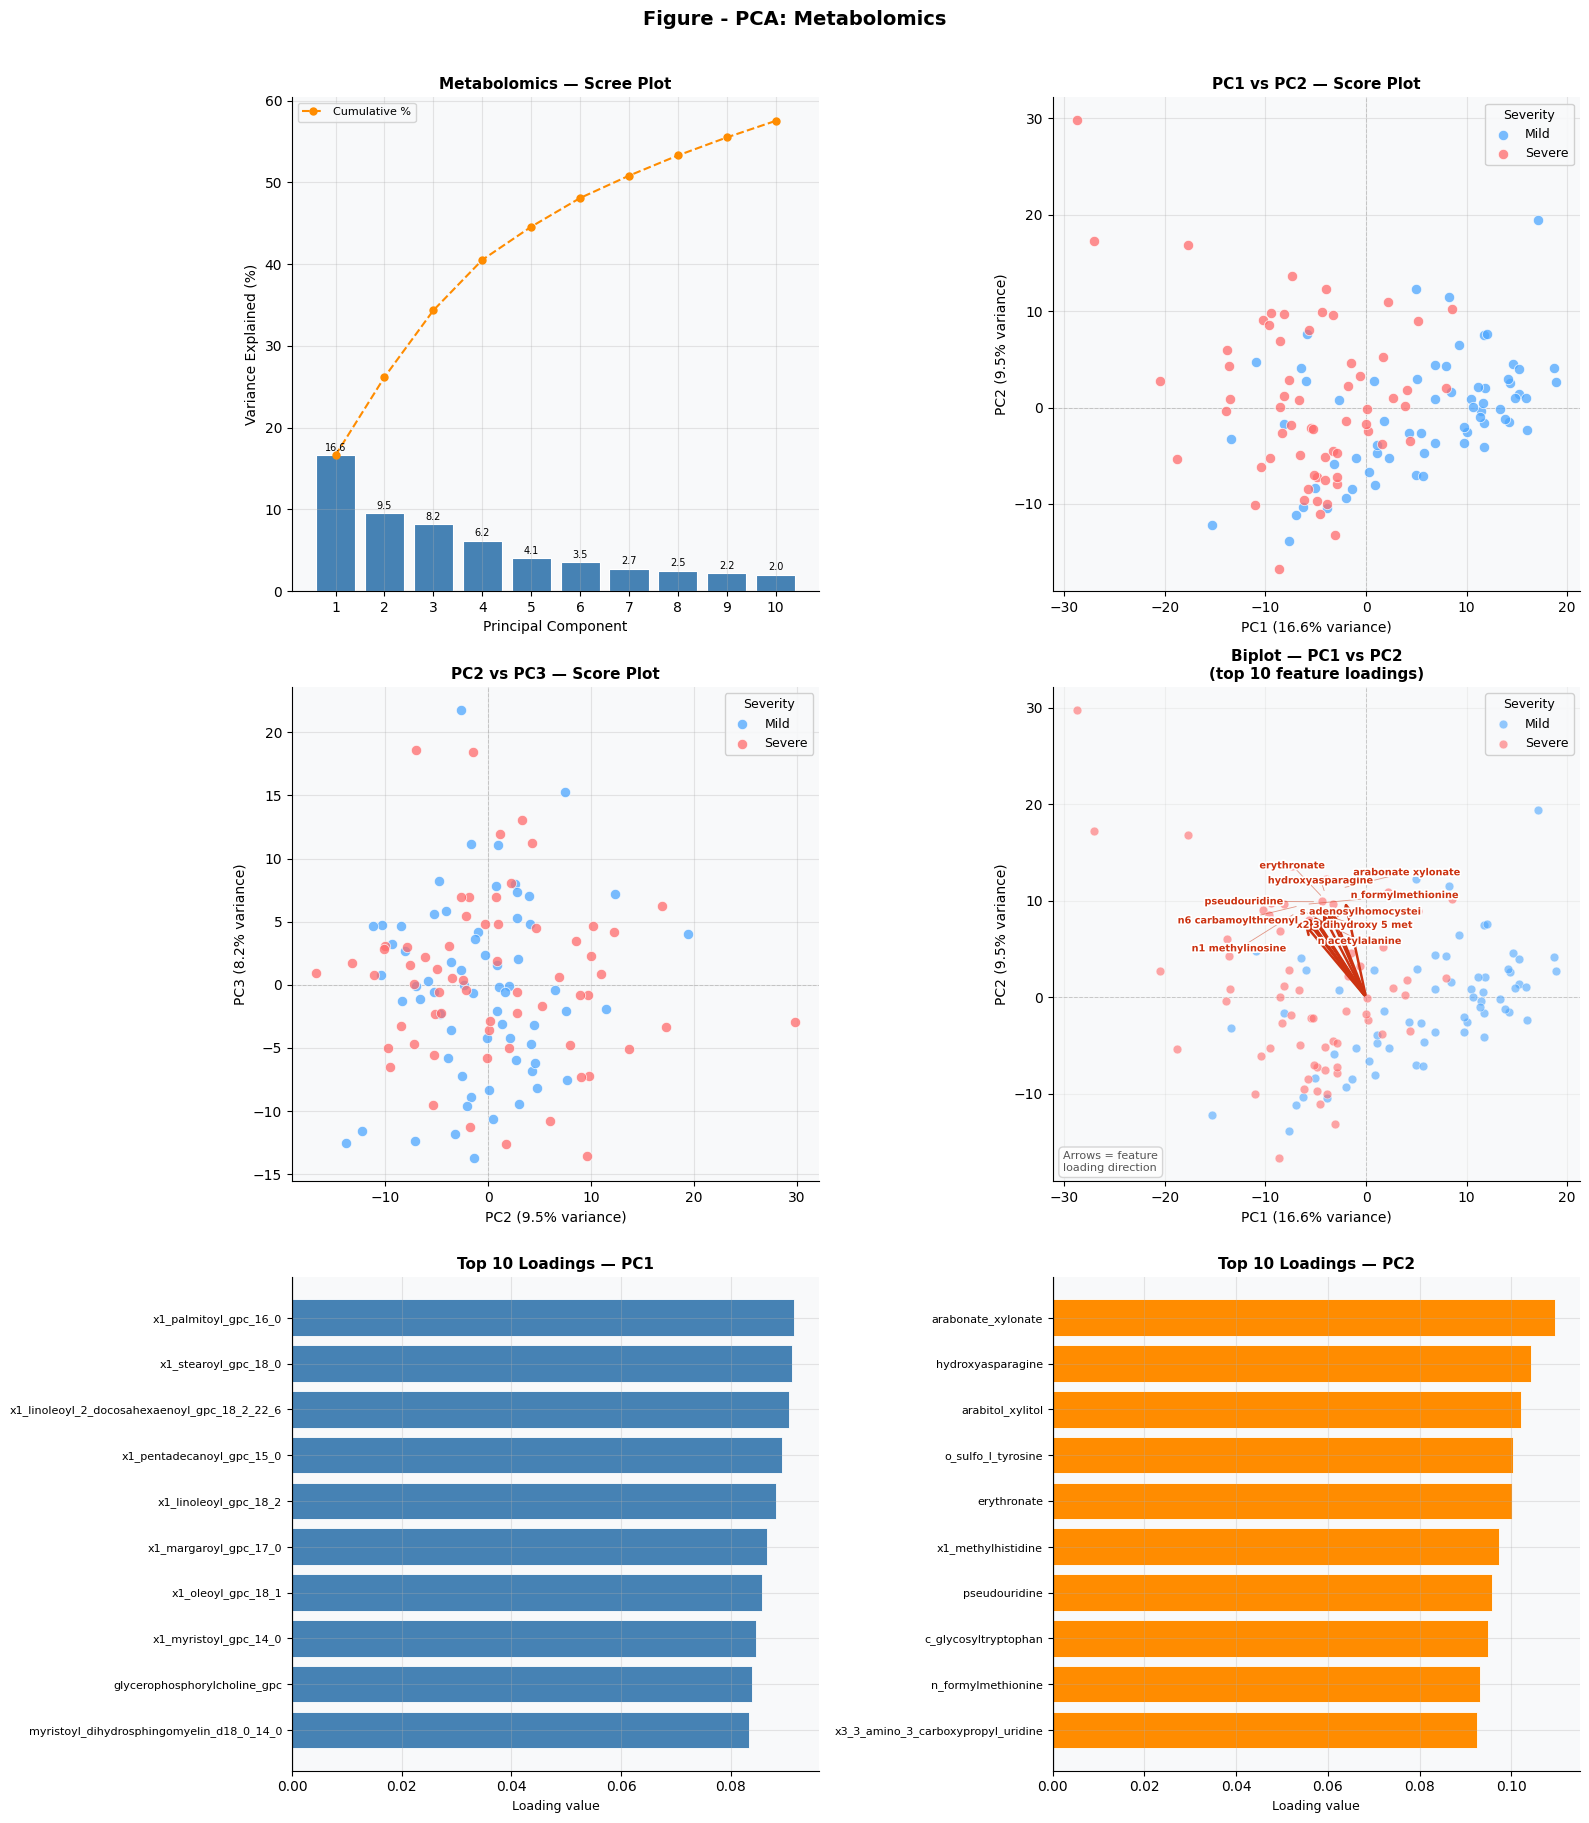

  Saved: fig3b_pca_metabolomics_v2.png


In [ ]:
# PCA Plots

def run_pca_plots_v2(X_raw, feat_cols, y, label, color_map, fig_fname, n_top_loadings=10):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    pca = PCA(n_components=min(30, X_raw.shape[1]), random_state=42)
    scores = pca.fit_transform(X_scaled)
    loadings = pd.DataFrame(pca.components_.T, index=feat_cols,
                            columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    ev = pca.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle(f'Figure - PCA: {label}', fontsize=14, fontweight='bold', y=1.01)

    # ── Row 0, col 0: Scree plot ──────────────────────────────────────────────
    ax = axes[0, 0]
    n_show = min(10, len(ev))
    bars = ax.bar(range(1, n_show + 1), ev[:n_show],
                  color='steelblue', edgecolor='white', linewidth=0.8)
    ax.plot(range(1, n_show + 1), np.cumsum(ev[:n_show]),
            'o--', color='darkorange', lw=1.5, ms=5, label='Cumulative %')
    for bar, val in zip(bars, ev[:n_show]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xlabel('Principal Component', fontsize=10)
    ax.set_ylabel('Variance Explained (%)', fontsize=10)
    ax.set_title(f'{label} — Scree Plot', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xticks(range(1, n_show + 1))

    # ── Row 0, col 1: PC1 vs PC2 score plot ──────────────────────────────────
    ax = axes[0, 1]
    ax.set_facecolor('#F8F9FA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    ax.axvline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    for lbl, col in color_map.items():
        mask = y == (1 if lbl == 'Severe' else 0)
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   c=col, label=lbl, alpha=0.75, s=55,
                   edgecolors='white', linewidths=0.6, zorder=3)
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% variance)', fontsize=10)
    ax.set_title('PC1 vs PC2 — Score Plot', fontsize=11, fontweight='bold')
    ax.legend(title='Severity', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#CCCCCC')

    # ── Row 1, col 0: PC2 vs PC3 score plot ──────────────────────────────────
    ax = axes[1, 0]
    ax.set_facecolor('#F8F9FA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    ax.axvline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    for lbl, col in color_map.items():
        mask = y == (1 if lbl == 'Severe' else 0)
        ax.scatter(scores[mask, 1], scores[mask, 2],
                   c=col, label=lbl, alpha=0.75, s=55,
                   edgecolors='white', linewidths=0.6, zorder=3)
    ax.set_xlabel(f'PC2 ({ev[1]:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC3 ({ev[2]:.1f}% variance)', fontsize=10)
    ax.set_title('PC2 vs PC3 — Score Plot', fontsize=11, fontweight='bold')
    ax.legend(title='Severity', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#CCCCCC')

    # ── Row 1, col 1: biplot (PC1 vs PC2 + top loadings) ───────────────
    ax = axes[1, 1]
    ax.set_facecolor('#F8F9FA')
    ax.axhline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    ax.axvline(0, color='#CCCCCC', lw=0.7, ls='--', zorder=0)
    ax.grid(True, alpha=0.15, zorder=0)
    for lbl, col in color_map.items():
        mask = y == (1 if lbl == 'Severe' else 0)
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   c=col, label=lbl, alpha=0.6, s=40,
                   edgecolors='white', linewidths=0.5, zorder=3)
    loads2 = pca.components_[:2].T
    norms = np.linalg.norm(loads2, axis=1)
    top_b_idx = np.argsort(norms)[-n_top_loadings:]
    score_spread = np.percentile(np.abs(scores[:, :2]), 90)
    load_max = np.max(norms[top_b_idx])
    scale = score_spread / load_max * 0.75
    texts = []
    for i in top_b_idx:
        lx = loads2[i, 0] * scale
        ly = loads2[i, 1] * scale
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#CC3311',
                                   lw=1.8, mutation_scale=14), zorder=4)
        short = feat_cols[i].replace('_', ' ')[:20]
        t = ax.text(lx * 1.12, ly * 1.12, short,
                    fontsize=7, color='#CC3311', fontweight='bold',
                    ha='center', va='center', zorder=5)
        t.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])
        texts.append(t)
    try:
        adjustText.adjust_text(texts, ax=ax,
                               expand_text=(1.4, 1.5), expand_points=(1.3, 1.4),
                               arrowprops=dict(arrowstyle='-', color='#CC3311',
                                               lw=0.6, alpha=0.5))
    except Exception:
        pass
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% variance)', fontsize=10)
    ax.set_title(f'Biplot — PC1 vs PC2\n(top {n_top_loadings} feature loadings)',
                 fontsize=11, fontweight='bold')
    ax.legend(title='Severity', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#CCCCCC')
    ax.annotate('Arrows = feature\nloading direction',
                xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=8, color='#555555',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#CCCCCC', alpha=0.8))

    # ── Row 2, col 0: Top loadings PC1 ───────────────────────────────────────
    ax = axes[2, 0]
    top1 = loadings['PC1'].abs().nlargest(n_top_loadings)
    colors_bar1 = ['steelblue' if v > 0 else '#e06c75'
                   for v in loadings.loc[top1.index, 'PC1']]
    ax.barh(top1.index, loadings.loc[top1.index, 'PC1'],
            color=colors_bar1, edgecolor='white', linewidth=0.6)
    ax.axvline(0, color='black', lw=0.8)
    ax.invert_yaxis()
    ax.set_title(f'Top {n_top_loadings} Loadings — PC1', fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading value', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

    # ── Row 2, col 1: Top loadings PC2 ───────────────────────────────────────
    ax = axes[2, 1]
    top2 = loadings['PC2'].abs().nlargest(n_top_loadings)
    colors_bar2 = ['darkorange' if v > 0 else '#c678dd'
                   for v in loadings.loc[top2.index, 'PC2']]
    ax.barh(top2.index, loadings.loc[top2.index, 'PC2'],
            color=colors_bar2, edgecolor='white', linewidth=0.6)
    ax.axvline(0, color='black', lw=0.8)
    ax.invert_yaxis()
    ax.set_title(f'Top {n_top_loadings} Loadings — PC2', fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading value', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fig_fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fig_fname}')

# Run for both omics
print('--- CELL 3b: Improved PCA Plots ---')
print('\nProteomics:')
run_pca_plots_v2(Xp_raw, feat_cols_p, y, 'Proteomics', col_map,
                 'fig2b_pca_proteomics_v2.png')
print('\nMetabolomics:')
run_pca_plots_v2(Xm_raw, feat_cols_m, y, 'Metabolomics', col_map,
                 'fig3b_pca_metabolomics_v2.png')

In [ ]:
# Train/Test Split
train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.25, stratify=y, random_state=42
)
Xp_train, Xp_test   = Xp_raw[train_idx], Xp_raw[test_idx]
Xm_train, Xm_test   = Xm_raw[train_idx], Xm_raw[test_idx]
cov_train, cov_test  = cov_raw[train_idx], cov_raw[test_idx]
y_train, y_test      = y[train_idx], y[test_idx]
print(f'Train: {len(y_train)} samples ({(y_train==1).sum()} severe)')
print(f'Test:  {len(y_test)} samples  ({(y_test==1).sum()} severe)')


Train: 96 samples (47 severe)
Test:  33 samples  (16 severe)


--- METHOD 1: LASSO Classification (lambda.1se) ---

Proteomics:
  lambda.min -> C=429.19343 (AUC=0.915)
  lambda.1se -> C=0.09103 (AUC=0.852) [SELECTED]
    Proteomics: CV AUC=0.841
    Omic features selected: 10 -> ['pentraxin_3_long', 'c_mer_proto_oncogene_tyrosine_kinase', 'amphiregulin_amphiregulin_b', 'c_type_lectin_domain_family_4_member_c', 'triggering_receptor_expressed_on_myeloid_cells_1', 'cd1c_molecule', 'g_protein_coupled_receptor_64', 'hematopoietic_prostaglandin_d_synthase', 'capping_protein_actin_filament_gelsolin_like', 'vasohibin_1']
    Covariates with nonzero coeff: ['age', 'sex']
  TEST SET -> AUC=0.993  Acc=0.939  F1=0.933

Metabolomics:
  lambda.min -> C=2.02359 (AUC=0.853)
  lambda.1se -> C=0.06866 (AUC=0.784) [SELECTED]
    Metabolomics: CV AUC=0.773
    Omic features selected: 7 -> ['guanidinoacetate', 'mannose', 'gamma_glutamylphenylalanine', 'x1_myristoyl_gpc_14_0', 'eicosanedioate_c20_dc', 'x2_hydroxybutyrate_2_hydroxyisobutyrate', 'n_1_n_8_acetylspermidine

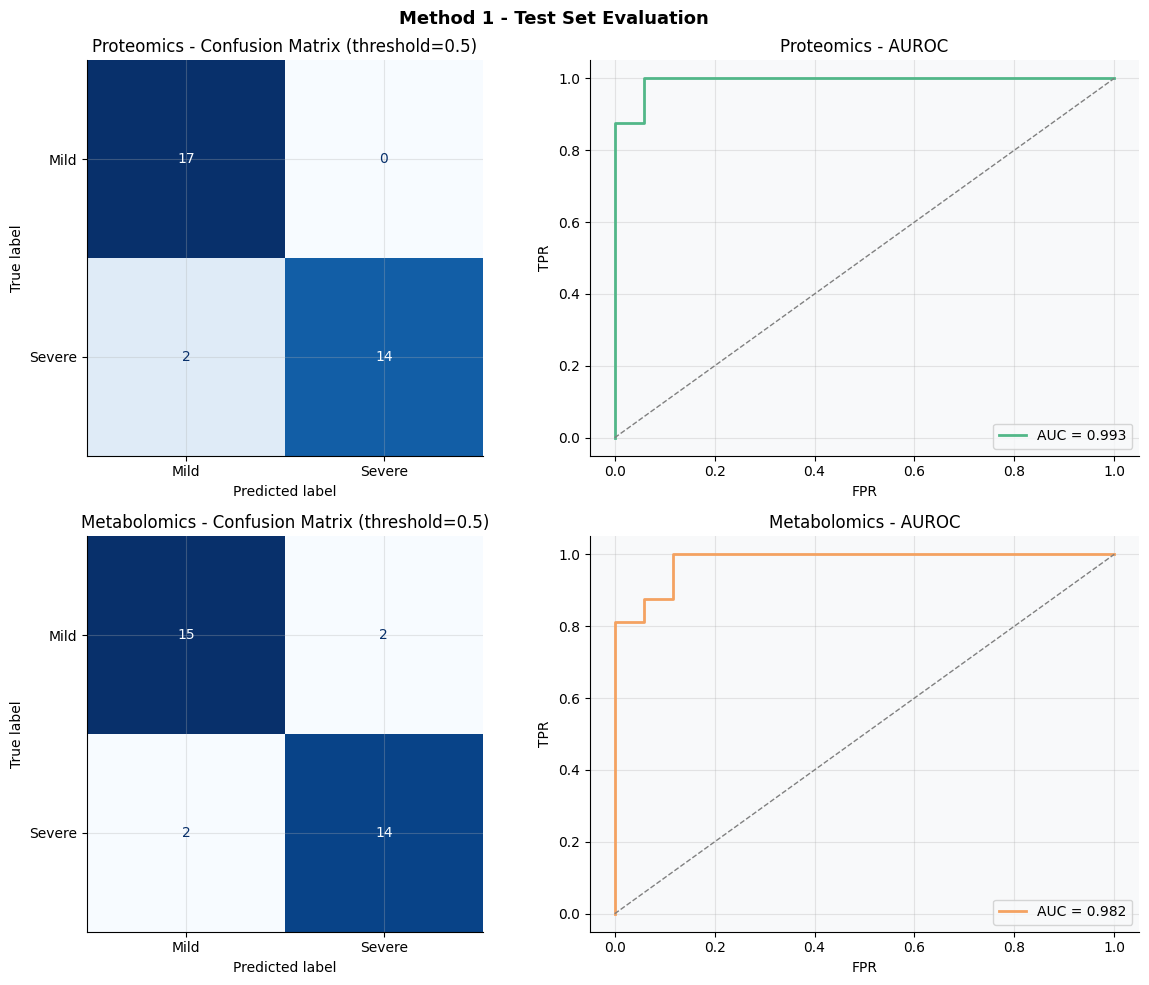

In [ ]:
# Method 1

def run_lasso_cv_fixed(X_train, feat_cols, y_tr, cov_tr, label, color, Cs, cv):
    """Train LASSO on train set, return pipeline + CV metrics."""
    feat_names = feat_cols + ['age', 'sex']
    X_tr = np.hstack([X_train, cov_tr])

    auc_means, auc_stds = [], []
    for C_val in Cs:
        pipe_search = Pipeline([
            ('scaler', StandardScaler()),
            ('lasso',  LogisticRegression(penalty='l1', solver='liblinear', C=C_val,
                                         class_weight='balanced', max_iter=2000, random_state=42))
        ])
        sc = cross_val_score(pipe_search, X_tr, y_tr, cv=cv, scoring='roc_auc')
        auc_means.append(sc.mean()); auc_stds.append(sc.std())

    auc_means = np.array(auc_means); auc_stds = np.array(auc_stds)
    best_idx  = np.argmax(auc_means)
    threshold = auc_means[best_idx] - auc_stds[best_idx]


    candidates = np.where((auc_means >= threshold) & (np.arange(len(Cs)) <= best_idx))[0]
    C_1se = Cs[candidates[0]]

    print(f'  lambda.min -> C={Cs[best_idx]:.5f} (AUC={auc_means[best_idx]:.3f})')
    print(f'  lambda.1se -> C={C_1se:.5f} (AUC={auc_means[candidates[0]]:.3f}) [SELECTED]')

    # Build final pipeline with chosen C
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso',  LogisticRegression(penalty='l1', solver='liblinear', C=C_1se,
                                     class_weight='balanced', max_iter=2000, random_state=42))
    ])

    # CV metrics on train set
    oof_probs = cross_val_predict(pipe, X_tr, y_tr, cv=cv, method='predict_proba')[:,1]
    cv_metrics = dict(
        AUC=roc_auc_score(y_tr, oof_probs),
        Acc=accuracy_score(y_tr, (oof_probs>=0.5).astype(int)),
        F1=f1_score(y_tr, (oof_probs>=0.5).astype(int)),
        Prec=precision_score(y_tr, (oof_probs>=0.5).astype(int)),
        Rec=recall_score(y_tr, (oof_probs>=0.5).astype(int))
    )

    # Fit on all train data
    pipe.fit(X_tr, y_tr)
    coef      = pipe.named_steps['lasso'].coef_[0]
    sel_mask  = coef != 0

    # Omic features selected
    sel_feats = [feat_names[i] for i in range(len(feat_names))
                 if sel_mask[i] and feat_names[i] in feat_cols]


    cov_selected = [feat_names[i] for i in range(len(feat_names))
                    if sel_mask[i] and feat_names[i] in ['age', 'sex']]

    print(f'    {label}: CV AUC={cv_metrics["AUC"]:.3f}')
    print(f'    Omic features selected: {len(sel_feats)} -> {sel_feats}')
    if cov_selected:
        print(f'    Covariates with nonzero coeff: {cov_selected}')
    else:
        print(f'    Covariates: age and sex both zeroed out by LASSO')

    return {'pipeline': pipe, 'X_tr': X_tr, 'features': sel_feats,
            'cov_selected': cov_selected, 'cv_metrics': cv_metrics,
            'coef': coef, 'feat_names': feat_names}


Cs_grid = np.logspace(-3, 3, 50)

print('--- METHOD 1: LASSO Classification (lambda.1se) ---')
print('\nProteomics:')
res_p        = run_lasso_cv_fixed(Xp_train, feat_cols_p, y_train, cov_train,
                                  'Proteomics', C['prot'], Cs_grid, CV5)
feats_p_new  = res_p['features']
pipe_p_final = res_p['pipeline']

Xp_test_full = np.hstack([Xp_test, cov_test])
prob_p_test  = pipe_p_final.predict_proba(Xp_test_full)[:,1]
pred_p_test  = (prob_p_test >= 0.5).astype(int)
met_p_test   = dict(
    AUC=roc_auc_score(y_test, prob_p_test),
    Acc=accuracy_score(y_test, pred_p_test),
    F1=f1_score(y_test, pred_p_test),
    Prec=precision_score(y_test, pred_p_test),
    Rec=recall_score(y_test, pred_p_test)
)
print(f'  TEST SET -> AUC={met_p_test["AUC"]:.3f}  Acc={met_p_test["Acc"]:.3f}  F1={met_p_test["F1"]:.3f}')

print('\nMetabolomics:')
res_m        = run_lasso_cv_fixed(Xm_train, feat_cols_m, y_train, cov_train,
                                  'Metabolomics', C['metab'], Cs_grid, CV5)
feats_m_new  = res_m['features']
pipe_m_final = res_m['pipeline']

Xm_test_full = np.hstack([Xm_test, cov_test])
prob_m_test  = pipe_m_final.predict_proba(Xm_test_full)[:,1]
pred_m_test  = (prob_m_test >= 0.5).astype(int)
met_m_test   = dict(
    AUC=roc_auc_score(y_test, prob_m_test),
    Acc=accuracy_score(y_test, pred_m_test),
    F1=f1_score(y_test, pred_m_test),
    Prec=precision_score(y_test, pred_m_test),
    Rec=recall_score(y_test, pred_m_test)
)
print(f'  TEST SET -> AUC={met_m_test["AUC"]:.3f}  Acc={met_m_test["Acc"]:.3f}  F1={met_m_test["F1"]:.3f}')

# Confusion matrices + AUROC curves
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Method 1 - Test Set Evaluation', fontsize=13, fontweight='bold')
for row, (label_name, prob, pred, col) in enumerate([
    ('Proteomics',   prob_p_test, pred_p_test, C['prot']),
    ('Metabolomics', prob_m_test, pred_m_test, C['metab'])
]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Mild', 'Severe']).plot(
        ax=axes[row,0], colorbar=False, cmap='Blues')
    axes[row,0].set_title(f'{label_name} - Confusion Matrix (threshold=0.5)')
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[row,1].plot(fpr, tpr, color=col, lw=2, label=f'AUC = {auc_val:.3f}')
    axes[row,1].plot([0,1],[0,1], '--', color='grey', lw=1)
    axes[row,1].set_xlabel('FPR'); axes[row,1].set_ylabel('TPR')
    axes[row,1].set_title(f'{label_name} - AUROC')
    axes[row,1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_method1_test_eval.png'), dpi=140, bbox_inches='tight')
plt.show()


--- CV Lambda Plots ---


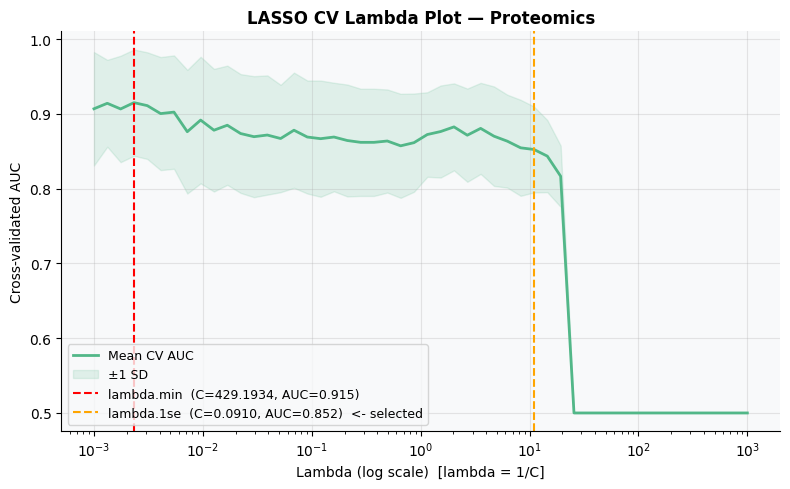

Proteomics: lambda.min=1/429.19343 | lambda.1se=1/0.09103
  lambda.min: best CV AUC, selects more features, less conservative
  lambda.1se: within 1 SE of best, fewer features, more generalisable -> SELECTED


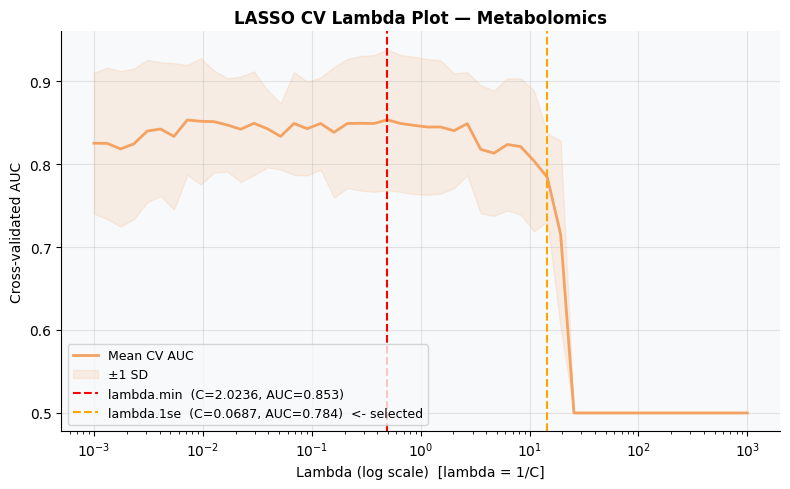

Metabolomics: lambda.min=1/2.02359 | lambda.1se=1/0.06866
  lambda.min: best CV AUC, selects more features, less conservative
  lambda.1se: within 1 SE of best, fewer features, more generalisable -> SELECTED


In [ ]:
# CV Lambda Plot: AUC vs C (regularisation strength) for LASSO

def plot_cv_lambda(X_train, feat_cols, y_tr, cov_tr, label, color, Cs, cv):
    """Reproduce the CV AUC grid and plot it."""
    X_tr = np.hstack([X_train, cov_tr])

    auc_means, auc_stds = [], []
    for C_val in Cs:

        pipe_search = Pipeline([
            ('scaler', StandardScaler()),
            ('lasso',  LogisticRegression(penalty='l1', solver='liblinear', C=C_val,
                                         class_weight='balanced', max_iter=2000, random_state=42))
        ])
        sc = cross_val_score(pipe_search, X_tr, y_tr, cv=cv, scoring='roc_auc')
        auc_means.append(sc.mean()); auc_stds.append(sc.std())

    auc_means = np.array(auc_means); auc_stds = np.array(auc_stds)
    best_idx  = np.argmax(auc_means)
    threshold = auc_means[best_idx] - auc_stds[best_idx]


    candidates = np.where((auc_means >= threshold) & (np.arange(len(Cs)) <= best_idx))[0]
    C_min = Cs[best_idx]
    C_1se = Cs[candidates[0]]

    lambdas = 1.0 / Cs

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogx(lambdas, auc_means, color=color, lw=2, label='Mean CV AUC')
    ax.fill_between(lambdas, auc_means - auc_stds, auc_means + auc_stds,
                    alpha=0.15, color=color, label='±1 SD')
    ax.axvline(1/C_min, color='red',    ls='--', lw=1.5,
               label=f'lambda.min  (C={C_min:.4f}, AUC={auc_means[best_idx]:.3f})')
    ax.axvline(1/C_1se, color='orange', ls='--', lw=1.5,
               label=f'lambda.1se  (C={C_1se:.4f}, AUC={auc_means[candidates[0]]:.3f})  <- selected')

    ax.set_xlabel('Lambda (log scale)  [lambda = 1/C]')
    ax.set_ylabel('Cross-validated AUC')
    ax.set_title(f'LASSO CV Lambda Plot — {label}', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'fig_cv_lambda_{label.lower()}.png'), dpi=140, bbox_inches='tight')
    plt.show()

    print(f'{label}: lambda.min=1/{C_min:.5f} | lambda.1se=1/{C_1se:.5f}')
    print(f'  lambda.min: best CV AUC, selects more features, less conservative')
    print(f'  lambda.1se: within 1 SE of best, fewer features, more generalisable -> SELECTED')

print('--- CV Lambda Plots ---')
plot_cv_lambda(Xp_train, feat_cols_p, y_train, cov_train, 'Proteomics',  C['prot'],  Cs_grid, CV5)
plot_cv_lambda(Xm_train, feat_cols_m, y_train, cov_train, 'Metabolomics', C['metab'], Cs_grid, CV5)


--- Boxplots: Top LASSO-Selected Features ---

Proteomics:


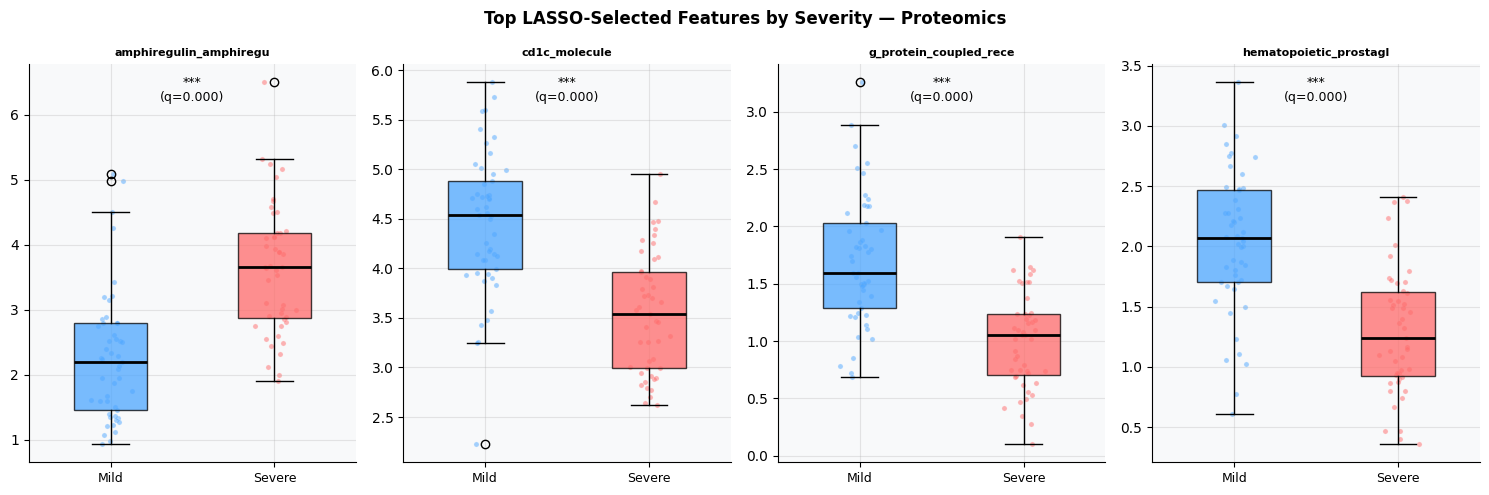


Metabolomics:


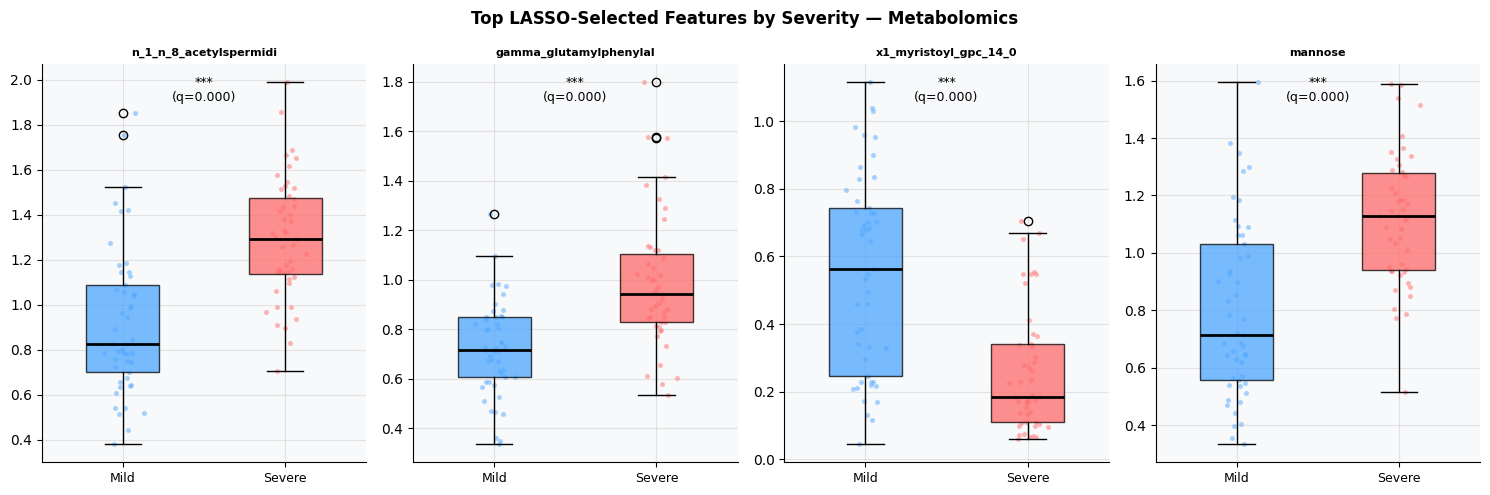

In [ ]:
# Boxplots of Top LASSO-Selected Features by Severity

def plot_feature_boxplots(X_data, feat_cols, feats_selected, y_data, label,
                          color_pair, fig_fname, n=4):
    """Plot top n LASSO-selected features as boxplots Mild vs Severe with FDR q-values."""
    pvals = []
    for f in feats_selected:
        fi = feat_cols.index(f)
        _, p = mannwhitneyu(X_data[y_data==0, fi], X_data[y_data==1, fi], alternative='two-sided')
        pvals.append(p)
    _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

    order     = np.argsort(pvals_fdr)
    top_feats = [feats_selected[i] for i in order[:n]]
    top_qs    = [pvals_fdr[i]      for i in order[:n]]

    fig, axes = plt.subplots(1, n, figsize=(3.5*n + 1, 5))
    if n == 1: axes = [axes]
    fig.suptitle(f'Top LASSO-Selected Features by Severity — {label}',
                 fontsize=12, fontweight='bold')

    for ax, feat, q in zip(axes, top_feats, top_qs):
        fi = feat_cols.index(feat)
        vals_mild   = X_data[y_data==0, fi]
        vals_severe = X_data[y_data==1, fi]

        bp = ax.boxplot([vals_mild, vals_severe], patch_artist=True,
                        medianprops=dict(color='black', lw=2), widths=0.45)
        for b, col in zip(bp['boxes'], color_pair):
            b.set_facecolor(col); b.set_alpha(0.75)

        for xi, vals, col in [(1, vals_mild, color_pair[0]), (2, vals_severe, color_pair[1])]:
            jitter = np.random.default_rng(42).normal(0, 0.06, len(vals))
            ax.scatter(xi + jitter, vals, color=col, alpha=0.5, s=14,
                       edgecolors='white', lw=0.3)

        sig = '***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05 else 'ns'
        ax.set_title(feat[:22], fontsize=8, fontweight='bold')
        ax.text(0.5, 0.97, f'{sig}\n(q={q:.3f})', transform=ax.transAxes,
                ha='center', va='top', fontsize=9)
        ax.set_xticks([1, 2]); ax.set_xticklabels(['Mild', 'Severe'], fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fig_fname), dpi=140, bbox_inches='tight')
    plt.show()

print('--- Boxplots: Top LASSO-Selected Features ---')

print('\nProteomics:')
plot_feature_boxplots(Xp_raw[train_idx], feat_cols_p, feats_p_new, y_train,
                      'Proteomics',   [C['mild'], C['severe']],
                      'fig_boxplots_proteomics.png', n=4)

print('\nMetabolomics:')
plot_feature_boxplots(Xm_raw[train_idx], feat_cols_m, feats_m_new, y_train,
                      'Metabolomics', [C['mild'], C['severe']],
                      'fig_boxplots_metabolomics.png', n=4)


--- Improved Biplots ---


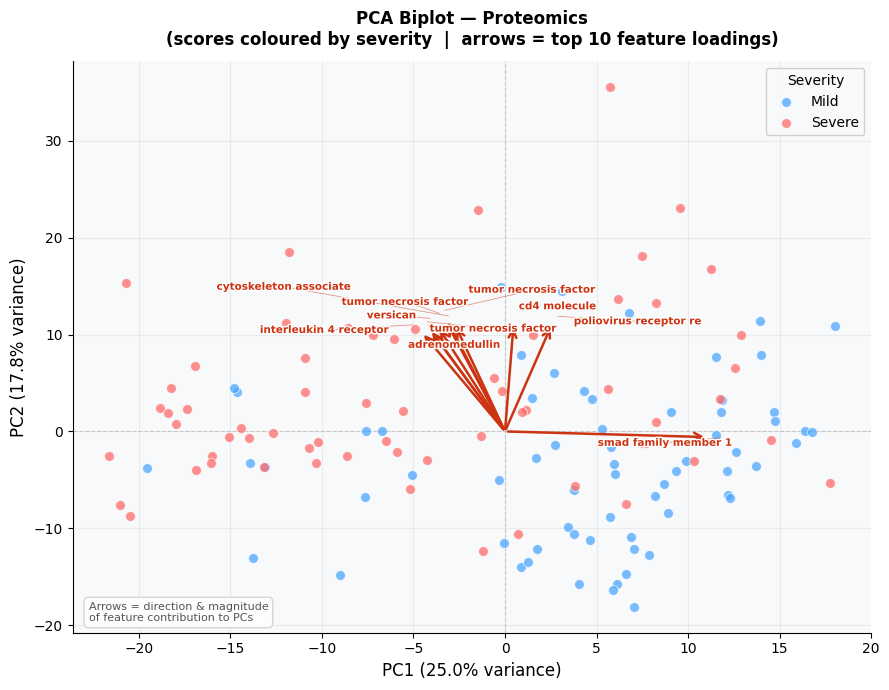

Proteomics: PC1=25.0%, PC2=17.8%  |  top loadings shown: 10


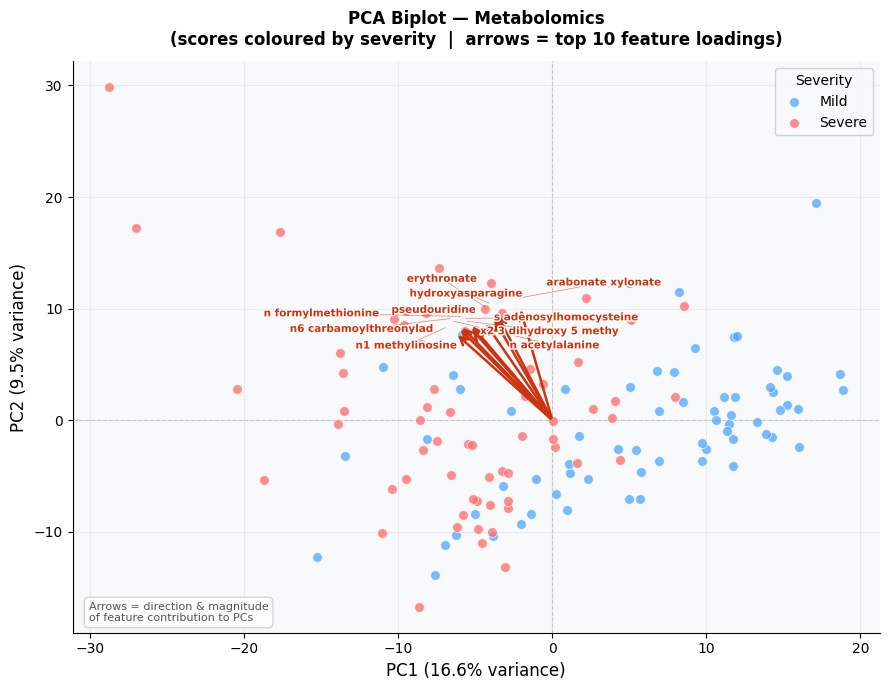

Metabolomics: PC1=16.6%, PC2=9.5%  |  top loadings shown: 10


In [ ]:
# Biplots (PCA scores + loadings)

def biplot_improved(scaler_fit, pca_fit, X_raw, feat_cols, y_arr, label,
                    n_loadings=10, color_scores=None):
    """Clean biplot reusing the already-fitted scaler and PCA from Cell 3/4.
    FIX: was refitting PCA from scratch (n_components=2), which could give
    slightly different PC directions/variance numbers than the EDA plots.
    Now takes the stored scaler_fit and pca_fit objects directly.
    """
    if color_scores is None:
        color_scores = {'Mild': C['mild'], 'Severe': C['severe']}

    # Reuse fitted objects — no refit
    scores_all = pca_fit.transform(scaler_fit.transform(X_raw))
    scores = scores_all[:, :2]
    loads  = pca_fit.components_[:2].T   # (n_features, 2)
    ev     = pca_fit.explained_variance_ratio_[:2] * 100

    score_spread = np.percentile(np.abs(scores), 90)
    load_max     = np.max(np.linalg.norm(loads, axis=1))
    scale        = score_spread / load_max * 0.75

    norms   = np.linalg.norm(loads, axis=1)
    top_idx = np.argsort(norms)[-n_loadings:]

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#F8F9FA')
    ax.axhline(0, color='#CCCCCC', lw=0.8, ls='--', zorder=0)
    ax.axvline(0, color='#CCCCCC', lw=0.8, ls='--', zorder=0)
    ax.grid(True, alpha=0.2, zorder=0)

    for lbl, col in color_scores.items():
        mask = y_arr == (1 if lbl == 'Severe' else 0)
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   c=col, label=lbl, alpha=0.75, s=50,
                   edgecolors='white', linewidths=0.6, zorder=3)

    texts = []
    for i in top_idx:
        lx = loads[i, 0] * scale
        ly = loads[i, 1] * scale
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#CC3311',
                                   lw=1.8, mutation_scale=14), zorder=4)
        short = feat_cols[i].replace('_', ' ')[:22]
        t = ax.text(lx * 1.08, ly * 1.08, short,
                    fontsize=7.5, color='#CC3311', fontweight='bold',
                    ha='center', va='center', zorder=5)
        t.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
        texts.append(t)

    try:
        adjustText.adjust_text(texts, ax=ax,
                               expand_text=(1.3, 1.4), expand_points=(1.2, 1.3),
                               arrowprops=dict(arrowstyle='-', color='#CC3311',
                                               lw=0.6, alpha=0.5))
    except Exception:
        pass

    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% variance)', fontsize=12)
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% variance)', fontsize=12)
    ax.set_title(f'PCA Biplot — {label}\n'
                 f'(scores coloured by severity  |  arrows = top {n_loadings} feature loadings)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.legend(title='Severity', fontsize=10, title_fontsize=10,
              framealpha=0.9, edgecolor='#CCCCCC')
    ax.annotate('Arrows = direction & magnitude\nof feature contribution to PCs',
                xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, color='#555555',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#CCCCCC', alpha=0.8))
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'fig_biplot_{label.lower()}.png'),
                dpi=160, bbox_inches='tight')
    plt.show()
    print(f'{label}: PC1={ev[0]:.1f}%, PC2={ev[1]:.1f}%  |  top loadings shown: {n_loadings}')

print('--- Improved Biplots ---')
# Pass the already-fitted scaler and PCA objects from Cells 3/4
biplot_improved(scaler_p_eda, pca_p_eda, Xp_raw, feat_cols_p, y, 'Proteomics',  n_loadings=10)
biplot_improved(scaler_m_eda, pca_m_eda, Xm_raw, feat_cols_m, y, 'Metabolomics', n_loadings=10)


--- METHOD 2: Random Forest (Early Integration) ---
Combined matrix: (96, 1017) train, (33, 1017) test
Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.15, 'max_depth': 20, 'class_weight': 'balanced'}
Best CV AUC: 0.865

RF TEST SET -> AUC=0.983  Acc=0.939  F1=0.938


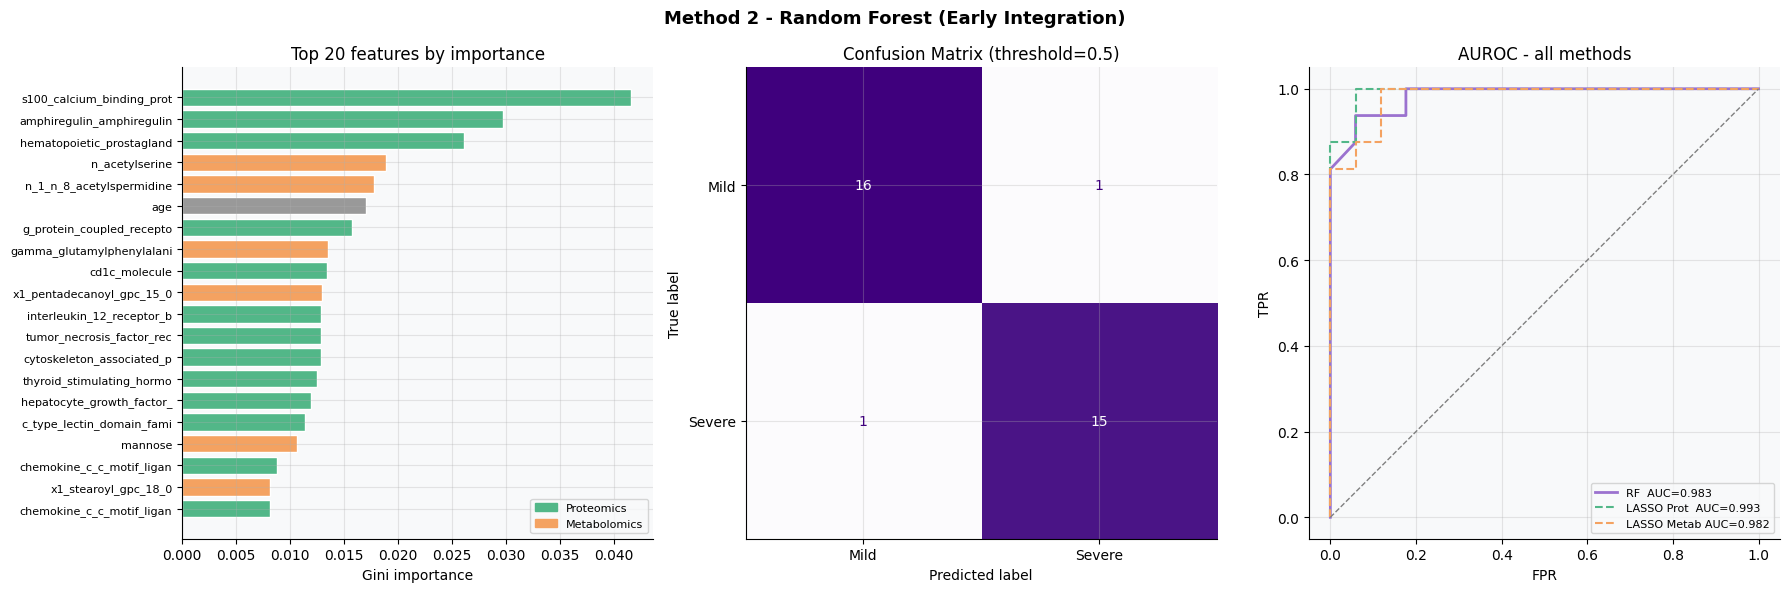


LASSO selected: 17 features total
RF top 20 overlapping with LASSO: 8
Overlap: {'hematopoietic_prostaglandin_d_synthase', 'n_1_n_8_acetylspermidine', 'c_type_lectin_domain_family_4_member_c', 'gamma_glutamylphenylalanine', 'mannose', 'amphiregulin_amphiregulin_b', 'g_protein_coupled_receptor_64', 'cd1c_molecule'}


In [ ]:


print('--- METHOD 2: Random Forest (Early Integration) ---')

X_comb_train    = np.hstack([Xp_train, Xm_train, cov_train])
X_comb_test     = np.hstack([Xp_test,  Xm_test,  cov_test])
feat_names_comb = feat_cols_p + feat_cols_m + ['age', 'sex']
print(f'Combined matrix: {X_comb_train.shape} train, {X_comb_test.shape} test')

param_grid = {
    'n_estimators':     [300, 500],
    'max_features':     ['sqrt', 0.1, 0.15],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'class_weight':     ['balanced']
}
rf_base   = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_grid,
    n_iter=20, cv=CV5,
    scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_comb_train, y_train)
best_rf = rf_search.best_estimator_
print(f'Best params: {rf_search.best_params_}')
print(f'Best CV AUC: {rf_search.best_score_:.3f}')

prob_rf_test = best_rf.predict_proba(X_comb_test)[:,1]
pred_rf_test = (prob_rf_test >= 0.5).astype(int)
met_rf_test  = dict(
    AUC=roc_auc_score(y_test, prob_rf_test),
    Acc=accuracy_score(y_test, pred_rf_test),
    F1=f1_score(y_test, pred_rf_test),
    Prec=precision_score(y_test, pred_rf_test),
    Rec=recall_score(y_test, pred_rf_test)
)
print(f'\nRF TEST SET -> AUC={met_rf_test["AUC"]:.3f}  '
      f'Acc={met_rf_test["Acc"]:.3f}  F1={met_rf_test["F1"]:.3f}')

importances  = pd.Series(best_rf.feature_importances_, index=feat_names_comb)
top_rf       = importances.nlargest(20)
omic_tag     = ['Prot' if f in feat_cols_p else ('Metab' if f in feat_cols_m else 'Cov')
                for f in top_rf.index]
colors_fi    = [C['prot'] if t=='Prot' else C['metab'] if t=='Metab' else '#999'
                for t in omic_tag]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Method 2 - Random Forest (Early Integration)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.barh(range(len(top_rf)), top_rf.values, color=colors_fi, edgecolor='white')
ax.set_yticks(range(len(top_rf)))
ax.set_yticklabels([f[:25] for f in top_rf.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Gini importance')
ax.set_title('Top 20 features by importance')
ax.legend(handles=[Patch(color=C['prot'], label='Proteomics'),
                   Patch(color=C['metab'], label='Metabolomics')],
          fontsize=8, loc='lower right')

cm_rf = confusion_matrix(y_test, pred_rf_test)
ConfusionMatrixDisplay(cm_rf, display_labels=['Mild','Severe']).plot(
    ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('Confusion Matrix (threshold=0.5)')

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf_test)
axes[2].plot(fpr_rf, tpr_rf, color=C['combined'], lw=2,
             label=f'RF  AUC={met_rf_test["AUC"]:.3f}')
fpr_p2, tpr_p2, _ = roc_curve(y_test, prob_p_test)
fpr_m2, tpr_m2, _ = roc_curve(y_test, prob_m_test)
axes[2].plot(fpr_p2, tpr_p2, color=C['prot'],  lw=1.5, ls='--',
             label=f'LASSO Prot  AUC={met_p_test["AUC"]:.3f}')
axes[2].plot(fpr_m2, tpr_m2, color=C['metab'], lw=1.5, ls='--',
             label=f'LASSO Metab AUC={met_m_test["AUC"]:.3f}')
axes[2].plot([0,1],[0,1], '--', color='grey', lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('AUROC - all methods')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_method2_rf.png'), dpi=140, bbox_inches='tight')
plt.show()

lasso_all    = set(feats_p_new) | set(feats_m_new)
rf_top20_set = set(top_rf.index)
overlap      = lasso_all & rf_top20_set
print(f'\nLASSO selected: {len(lasso_all)} features total')
print(f'RF top 20 overlapping with LASSO: {len(overlap)}')
if overlap:
    print('Overlap:', overlap)


Method                                        AUC      Acc       F1     Prec      Rec
M1: LASSO - Proteomics only                 0.993    0.939    0.933    1.000    0.875
M1: LASSO - Metabolomics only               0.982    0.879    0.875    0.875    0.875
M2: Random Forest - Combined                0.983    0.939    0.938    0.938    0.938


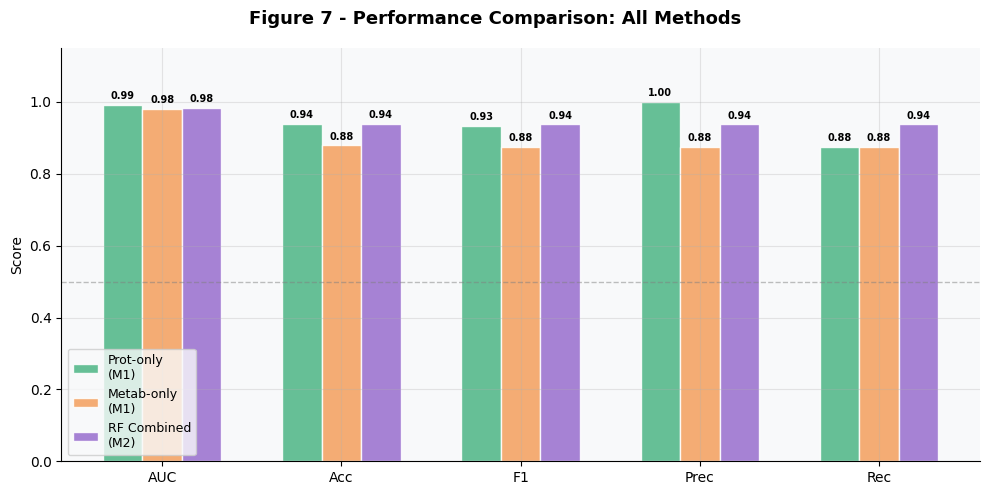


Note: All metrics evaluated on held-out test set (n=33, 25% stratified split)
CV AUC values (more reliable generalisation estimate):
  LASSO Prot  (CV): 0.841
  LASSO Metab (CV): 0.773
  RF          (CV): 0.865


In [ ]:
# Performance Comparison Table
print('=' * 65)
print(f"{'Method':<40}   {'AUC':>6}   {'Acc':>6}   {'F1':>6}   {'Prec':>6}   {'Rec':>6}")
print('=' * 65)
results = [
    ('M1: LASSO - Proteomics only',   met_p_test),
    ('M1: LASSO - Metabolomics only', met_m_test),
    ('M2: Random Forest - Combined',  met_rf_test),
]
for name, m in results:
    print(f"{name:<40}   {m['AUC']:>6.3f}   {m['Acc']:>6.3f}   {m['F1']:>6.3f}   {m['Prec']:>6.3f}   {m['Rec']:>6.3f}")
print('=' * 65)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 7 - Performance Comparison: All Methods', fontsize=13, fontweight='bold')
metrics_keys = ['AUC', 'Acc', 'F1', 'Prec', 'Rec']
names   = ['Prot-only\n(M1)', 'Metab-only\n(M1)', 'RF Combined\n(M2)']
colors  = [C['prot'], C['metab'], C['combined']]
x = np.arange(len(metrics_keys))
width = 0.22
for i, (m_dict, col, name) in enumerate(zip([met_p_test, met_m_test, met_rf_test], colors, names)):
    vals = [m_dict[k] for k in metrics_keys]
    bars = ax.bar(x + i*width - width, vals, width, label=name, color=col,
                  edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_keys)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig7_performance_comparison.png'), dpi=140, bbox_inches='tight')
plt.show()
print('\nNote: All metrics evaluated on held-out test set (n=33, 25% stratified split)')
print('CV AUC values (more reliable generalisation estimate):')
print(f'  LASSO Prot  (CV): {res_p["cv_metrics"]["AUC"]:.3f}')
print(f'  LASSO Metab (CV): {res_m["cv_metrics"]["AUC"]:.3f}')
print(f'  RF          (CV): {rf_search.best_score_:.3f}')


In [ ]:
# AUC Confidence Intervals (Hanley-McNeil 1982)

n_pos = int(y_test.sum())
n_neg = int((y_test == 0).sum())
print(f'Test set: n_pos (Severe)={n_pos}, n_neg (Mild)={n_neg}')

print(f'Hanley-McNeil 95% CI for test-set AUC (n_pos={n_pos}, n_neg={n_neg})')
print('=' * 60)
for name, auc in [
    ('LASSO Prot',  met_p_test['AUC']),
    ('LASSO Metab', met_m_test['AUC']),
    ('RF Combined', met_rf_test['AUC']),
]:
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se = np.sqrt((auc*(1-auc) + (n_pos-1)*(q1-auc**2) + (n_neg-1)*(q2-auc**2)) / (n_pos*n_neg))
    lo = max(0, auc - 1.96*se)
    hi = min(1, auc + 1.96*se)
    print(f'{name:<14}: AUC={auc:.3f}  SE={se:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
print('=' * 60)
print('Note: Wide CIs reflect small test set (n=33). CV AUC is the more reliable estimate.')


Test set: n_pos (Severe)=16, n_neg (Mild)=17
Hanley-McNeil 95% CI for test-set AUC (n_pos=16, n_neg=17)
LASSO Prot    : AUC=0.993  SE=0.016  95% CI [0.962, 1.000]
LASSO Metab   : AUC=0.982  SE=0.025  95% CI [0.933, 1.000]
RF Combined   : AUC=0.983  SE=0.023  95% CI [0.938, 1.000]
Note: Wide CIs reflect small test set (n=33). CV AUC is the more reliable estimate.
